# 🤖 Dota 2 — LangGraph RAG Агент

## Идея
Вместо того чтобы слепо искать по всем 2200+ документам, строим **агент с маршрутизацией**:

```
Запрос пользователя
    │
    ▼
[router_node]       ← Llama извлекает: коллекции, entity_name, entity_type
    │
    ▼
[search_node]       ← ChromaDB с фильтрами `where` по метаданным (точечный поиск)
    │
    ▼
[rerank_node]       ← BGE Reranker v2-m3 (cross-encoder) переоценивает кандидатов
    │
    ▼
[generate_node]     ← Llama 3.1-8B генерирует финальный ответ
    │
    ▼
  Ответ
```

## Зачем нужна маршрутизация?
Без маршрутизации: «способности Anti-Mage?» → поиск по всем героям + предметам + патчам  
С маршрутизацией: тот же запрос → `where={hero_name: "Anti-Mage"}` → **только ~10 документов этого героя**

---
## 1. Импорты и настройка окружения

In [1]:
import gc
import json
import os
import re
import time
from pathlib import Path
from typing import TypedDict, Optional, List, Any

import torch
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb
from chromadb.config import Settings
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from dotenv import load_dotenv

# LangGraph — фреймворк для построения агентов с графами состояний
from langgraph.graph import StateGraph, END

load_dotenv()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"   Устройство: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} ГБ")

c:\python\dota_ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Устройство: cuda
   GPU: NVIDIA GeForce RTX 5080
   VRAM: 17.1 ГБ


---
## 2. Загрузка модели эмбеддингов — BGE-M3

**BAAI/bge-m3** — мультиязычная embedding-модель:
- Размерность вектора: **1024**
- Максимальная длина: **8192 токенов**

In [2]:
BGE_M3_PATH = Path("models/bge-m3")

if BGE_M3_PATH.exists() and (BGE_M3_PATH / "config.json").exists():
    print(f"Загрузка BGE-M3 из локального кэша: {BGE_M3_PATH}")
    embedding_model = SentenceTransformer(str(BGE_M3_PATH))
else:
    print("Скачивание BAAI/bge-m3")
    embedding_model = SentenceTransformer("BAAI/bge-m3")
    BGE_M3_PATH.mkdir(parents=True, exist_ok=True)
    embedding_model.save(str(BGE_M3_PATH))
    print(f"Модель сохранена локально: {BGE_M3_PATH}")

dim = embedding_model.get_sentence_embedding_dimension()
max_len = embedding_model.max_seq_length
print(f"BGE-M3 готова")
print(f"Размерность эмбеддинга: {dim}")
print(f"Макс. длина токенов: {max_len}")

Загрузка BGE-M3 из локального кэша: models\bge-m3


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1692.58it/s, Materializing param=pooler.dense.weight]                               


BGE-M3 готова
Размерность эмбеддинга: 1024
Макс. длина токенов: 8192


---
## 3. Инициализация ChromaDB

Три коллекции с разными метаданными для фильтрации:

| Коллекция | Поля метаданных |
|---|---|
| `dota2_heroes` | `hero_name`, `hero_id`, [`ability_id`, `ability_name`] для способностей, [`talents_count`] для талантов, [`chunk_id`] для лора |
| `dota2_items` | `item_name`, `item_id`, `slug`, `category`, `cost` |
| `dota2_patches` | `patch_version`, `entity_type` (hero/item/general), [`hero_name`] только у hero-записей |

> **Важно:** в героях нет поля `source` — тип документа определяется по наличию других полей (`ability_id`, `facets_count` и т.д.).

In [3]:
CHROMADB_PATH = "data/chromadb"

client = chromadb.PersistentClient(
    path=CHROMADB_PATH,
    settings=Settings(anonymized_telemetry=False),
)

COLLECTION_NAMES = ["dota2_heroes", "dota2_items", "dota2_patches"]

print("ChromaDB клиент подключён")
print(f"Путь: {Path(CHROMADB_PATH).absolute()}")
print()

# Выводим количество документов и пример ключей метаданных
for name in COLLECTION_NAMES:
    try:
        coll = client.get_collection(name)
        count = coll.count()
        # Смотрим на один документ, чтобы показать ключи метаданных
        peek = coll.peek(1)
        meta_keys = list(peek["metadatas"][0].keys()) if peek["metadatas"] else []
        print(f"{name}: {count:,} документов, ключи метаданных: {meta_keys}")
    except Exception as e:
        print(f"{name}: коллекция не найдена ({e})")

ChromaDB клиент подключён
Путь: c:\python\dota_ai\data\chromadb

dota2_heroes: 1,268 документов, ключи метаданных: ['language', 'primary_attr', 'hero_name', 'hero_id', 'complexity']
dota2_items: 475 документов, ключи метаданных: ['neutral_tier', 'item_name', 'cost', 'item_id', 'slug', 'language', 'category']
dota2_patches: 327 документов, ключи метаданных: ['entity_type', 'patch_version', 'language', 'chunk_id', 'total_chunks']


---
## 4. Загрузка реранкера — BGE Reranker v2-m3

**Cross-encoder** оценивает пару *(запрос, документ)* совместно — модель видит оба текста одновременно.  
Это гораздо точнее, чем bi-encoder (который кодирует запрос и документ раздельно), но медленнее.

**Архитектурное замечание:** основан на XLM-RoBERTa, жёсткий лимит — **512 токенов на пару**.  
Поэтому используем его как второй этап: bi-encoder быстро достаёт 30 кандидатов, cross-encoder точно их переоценивает.

Стратегия: `N=10` кандидатов из каждой коллекции (30 итого) → реранкер выбирает топ `K=5`.

In [4]:
RERANKER_PATH = Path("models/bge-reranker-v2-m3")
RERANKER_NAME = "BAAI/bge-reranker-v2-m3"

if RERANKER_PATH.exists() and (RERANKER_PATH / "config.json").exists():
    print(f"Загрузка реранкера из локального кэша: {RERANKER_PATH}")
    reranker = CrossEncoder(str(RERANKER_PATH), max_length=512)
else:
    print(f"Скачивание {RERANKER_NAME}")
    reranker = CrossEncoder(RERANKER_NAME, max_length=512)
    RERANKER_PATH.mkdir(parents=True, exist_ok=True)
    reranker.save(str(RERANKER_PATH))
    print(f"Реранкер сохранён локально: {RERANKER_PATH}")

# Переносим на GPU, если доступен
if torch.cuda.is_available():
    reranker.model.to("cuda")

reranker_device = next(reranker.model.parameters()).device
print(f"BGE Reranker v2-m3 готов")
print(f"Устройство : {reranker_device}")
print(f"Макс. длина: 512 токенов на пару [запрос, документ]")

Загрузка реранкера из локального кэша: models\bge-reranker-v2-m3


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 1761.32it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              


BGE Reranker v2-m3 готов
Устройство : cuda:0
Макс. длина: 512 токенов на пару [запрос, документ]


---
## 5. Авторизация HuggingFace и загрузка Llama 3.2-3B

Llama 3.2-3B-Instruct используется в агенте для двух задач:
1. **Маршрутизатор (router)** — разбирает запрос пользователя на структурированный JSON-план (`temperature=0`, детерминированно)
2. **Генератор (generate)** — создаёт финальный ответ (`temperature=0.3`, слегка творчески)

### Почему 3B bfloat16?

На RTX 5080 (16 ГБ VRAM) одновременно живут три модели:

| Модель | VRAM |
|---|---|
| BGE-M3 | ~2.3 ГБ |
| BGE Reranker v2-m3 | ~0.6 ГБ |
| **Llama 3.2-3B (BF16)** | **~6.0 ГБ** |
| **Итого** | **~8.9 ГБ ✅** |

Llama 3.2-3B в bfloat16 не требует bitsandbytes — работает на любой CUDA-видеокарте,  
включая Blackwell (sm_120), без каких-либо проблем с DLL или квантизацией.

In [5]:
# ── Авторизация в HuggingFace ─────────────────────────────────────────────────
hf_token = os.getenv("HF_TOKEN")
use_token = False

if hf_token:
    try:
        from huggingface_hub import login, whoami
        login(token=hf_token, add_to_git_credential=False)
        user_info = whoami()
        # print(f"HF авторизован как: {user_info['name']}")
        use_token = True
    except Exception as e:
        print(f"Ошибка авторизации HF: {e}")
else:
    print("HF_TOKEN не найден в .env (это нормально, если модель уже скачана локально)")

# ── Загрузка Llama 3.2-3B-Instruct в bfloat16 — без квантования, без bitsandbytes ──
LLAMA_PATH = Path("models/llama3.2-3b")
LLAMA_HF_NAME = "meta-llama/Llama-3.2-3B-Instruct"

use_hf_download = not (LLAMA_PATH.exists() and (LLAMA_PATH / "config.json").exists())
model_source = LLAMA_HF_NAME if use_hf_download else str(LLAMA_PATH)
print(f"Загрузка Llama из: {model_source}")

gc.collect()
torch.cuda.empty_cache()

llama_tokenizer = AutoTokenizer.from_pretrained(
    model_source,
    token=hf_token if use_token else None,
)

llama_model = AutoModelForCausalLM.from_pretrained(
    model_source,
    torch_dtype=torch.bfloat16,
    device_map={"": "cuda:0"},   # явно: вся модель на GPU 0 (без CPU offload)
    attn_implementation="sdpa",  # встроенный FlashAttention от PyTorch
    token=hf_token if use_token else None,
)
llama_model.eval()

# Сохраняем локально, если была загрузка с HF (чтобы не скачивать повторно)
if use_hf_download:
    print(f"Сохранение в {LLAMA_PATH}")
    LLAMA_PATH.mkdir(parents=True, exist_ok=True)
    llama_tokenizer.save_pretrained(str(LLAMA_PATH))
    llama_model.save_pretrained(str(LLAMA_PATH))
    print("Сохранено.")

vram_used = torch.cuda.memory_allocated(0) / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"Llama 3.2-3B готова")
print(f"VRAM: {vram_used:.1f} / {vram_total:.1f} ГБ")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Загрузка Llama из: models\llama3.2-3b


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 254/254 [00:02<00:00, 121.63it/s, Materializing param=model.norm.weight]                              


Llama 3.2-3B готова
VRAM: 11.0 / 17.1 ГБ


---
## 6. Вспомогательные функции

Строительные блоки, которые переиспользуются во всех узлах агента.  

In [6]:
def generate_with_llama(
    prompt: str,
    max_new_tokens: int = 700,
    temperature: float = 0.3,
) -> str:
    """
    Генерирует текст с помощью Llama 3.1-8B-Instruct.
    Использует шаблон чата Llama3: [user] → [assistant].

    temperature=0.0 → детерминированный вывод (для маршрутизатора)
    temperature>0   → семплирование с top_p (для генератора ответов)
    """
    # Форматируем промпт согласно шаблону Llama3
    formatted = (
        "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n"
        f"{prompt}"
        "<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n"
    )
    inputs = llama_tokenizer(
        formatted,
        return_tensors="pt",
        truncation=True,
        max_length=2048,
    ).to(llama_model.device)

    # Llama3: токен конца ответа — <|eot_id|> (id=128009)
    eot_token_id = llama_tokenizer.convert_tokens_to_ids("<|eot_id|>")

    with torch.inference_mode():
        outputs = llama_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature if temperature > 0 else None,
            do_sample=temperature > 0,
            top_p=0.9 if temperature > 0 else None,
            repetition_penalty=1.1,
            eos_token_id=eot_token_id,          # остановиться на <|eot_id|>
            pad_token_id=llama_tokenizer.eos_token_id,
            use_cache=True,   # KV-cache: не пересчитываем токены промпта на каждом шаге
        )

    # Декодируем только новые токены (без промпта)
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return llama_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

In [7]:
def search_collection_with_filter(
    query: str,
    collection_name: str,
    n_results: int = 10,
    where: Optional[dict] = None,
) -> list:
    """
    Поиск в одной коллекции ChromaDB.
    BGE-M3: кодируем запрос напрямую, БЕЗ префиксов.
    Возвращает список словарей-кандидатов.
    """
    coll = client.get_collection(collection_name)

    # BGE-M3 — без префикса!
    query_emb = embedding_model.encode(query, convert_to_numpy=True)

    params: dict = {
        "query_embeddings": [query_emb.tolist()],
        "n_results": min(n_results, coll.count()),
        "include": ["documents", "metadatas", "distances"],
    }
    if where:
        params["where"] = where

    results = coll.query(**params)

    candidates = []
    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0],
    ):
        candidates.append({
            "text": doc,
            "similarity": float(1 - dist),   # косинусное расстояние → схожесть
            "collection": collection_name,
            "metadata": meta,
        })
    return candidates


def rerank_results(query: str, candidates: list, top_n: int = 5) -> list:
    """
    Реранкинг кандидатов с помощью cross-encoder.
    Оценивает каждую пару [запрос, документ] совместно.
    Возвращает top_n кандидатов, отсортированных по rerank_score (убывание).
    """
    if not candidates:
        return []

    pairs = [(query, c["text"]) for c in candidates]
    scores = reranker.predict(pairs, show_progress_bar=False)

    reranked = []
    for cand, score in zip(candidates, scores):
        item = dict(cand)
        item["rerank_score"] = float(score)
        item["bi_encoder_score"] = cand["similarity"]
        reranked.append(item)

    reranked.sort(key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:top_n]


def format_contexts_for_prompt(contexts: list) -> str:
    """Форматируем топ-контексты в пронумерованный список для промпта LLM."""
    if not contexts:
        return "Релевантный контекст не найден."

    COLL_LABEL = {
        "dota2_heroes": "База героев",
        "dota2_items": "База предметов",
        "dota2_patches": "История патчей",
    }
    parts = []
    for i, ctx in enumerate(contexts, 1):
        label = COLL_LABEL.get(ctx["collection"], ctx["collection"])
        parts.append(f"[Контекст {i}] Источник: {label}\n{ctx['text']}")
    return "\n\n".join(parts)

---
## 7. AgentState — общая доска состояния

Каждая функция-узел получает `state: AgentState` и возвращает `dict` **только с теми полями, которые она обновляет**.  
LangGraph автоматически сливает возвращённый dict в состояние.

```
state = {
    "query":             "Расскажи про способности Anti-Mage",   # входной запрос
    "router_output":     {"collections": [...], ...},             # заполняет router_node
    "raw_candidates":    [...],                                    # заполняет search_node
    "reranked_contexts": [...],                                    # заполняет rerank_node
    "answer":            "У Anti-Mage 4 способности: ..."         # заполняет generate_node
}
```

In [8]:
class AgentState(TypedDict):
    # Устанавливается вызывающим кодом
    query: str

    # Устанавливается router_node
    # Пример: {"collections": ["dota2_heroes"], "entity_name": "Anti-Mage", "entity_type": "hero"}
    router_output: dict

    # Устанавливается search_node — список кандидатов с полями:
    #   text, similarity, collection, metadata
    raw_candidates: list

    # Устанавливается rerank_node — то же, но с добавленным rerank_score
    reranked_contexts: list

    # Устанавливается generate_node — финальный ответ
    answer: str

---
## 8. Построитель фильтра `where` для ChromaDB

ChromaDB поддерживает структурированные фильтры по полям метаданных:

```python
# Фильтр только по имени героя
{"hero_name": {"$eq": "Anti-Mage"}}

# Фильтр по имени героя И типу записи в патчах
{"$and": [
    {"hero_name": {"$eq": "Anti-Mage"}},
    {"entity_type": {"$eq": "hero"}}
]}
```

Для запроса о способностях Anti-Mage это разница между:
- ❌ **все** ~1268 документов о героях (медленно, шумно — попадают патчи, предметы, таланты других героев)
- ✅ **только ~10 документов Anti-Mage** (быстро и точно)

> **Примечание:** в коллекции `dota2_heroes` нет поля `source`.  
> Тип документа определяется по наличию специфичных полей: `ability_id` → способность, `talents_count` → таланты, `chunk_id` → лор/биография.

In [9]:
def build_where_filter(
    entity_name: Optional[str],
    entity_type: Optional[str],
    collection: str,
) -> Optional[dict]:
    """
    Строим ChromaDB-фильтр `where` из полей router_output.

    Реальная схема метаданных:
      dota2_heroes  → hero_name, hero_id, [ability_id, ability_name, ...] (поле source отсутствует!)
      dota2_items   → item_name, item_id, slug, category, ...
      dota2_patches → patch_version, entity_type ("hero"/"item"/"general"), [hero_name]

    Возвращает None, если фильтр не нужен (полный скан коллекции).
    """
    conditions = []

    if entity_name:
        if collection == "dota2_heroes":
            conditions.append({"hero_name": {"$eq": entity_name}})
        elif collection == "dota2_items":
            conditions.append({"item_name": {"$eq": entity_name}})
        elif collection == "dota2_patches":
            # В патчах hero_name есть только у hero-записей (entity_type="hero")
            if entity_type == "hero":
                conditions.append({"hero_name": {"$eq": entity_name}})
                # Ограничиваемся только hero-записями в патчах (не general/item)
                conditions.append({"entity_type": {"$eq": "hero"}})

    if not conditions:
        return None   # нет фильтра → сканируем всю коллекцию
    if len(conditions) == 1:
        return conditions[0]
    return {"$and": conditions}

---
## 9. Узел-маршрутизатор (router_node)

Маршрутизатор — мозг агента. Он запускает Llama 3.1-8B с `temperature=0` (детерминированно) и разбирает запрос в структурированный план:

```json
{
  "collections":  ["dota2_heroes"],
  "entity_name":  "Anti-Mage",
  "entity_type":  "hero"
}
```

**Почему LLM, а не regex/правила?**  
LLM справляется с любыми формулировками:
- `"амазонка"` → находит имя героя даже в разговорной форме
- `"что дают штаны сила"` → запрос о предметах без слова «предмет»
- `"нерф инвокера 7.40"` → патчи + конкретный герой

**Защита от сбоев:** если JSON не удалось распарсить — используем fallback и ищем по всем коллекциям без фильтров.

Примечание: SYSTEM_PROMT на английском языке, потому что Llama лучше понимает инструкции на английском.

In [11]:
ROUTER_SYSTEM = """You are a query router for a Dota 2 knowledge base.
Analyze the question and return ONLY a JSON object with these fields:
- "collections": list, choose from ["dota2_heroes", "dota2_items", "dota2_patches"]
- "entity_name": string (exact English hero/item name), or null if the query is generic
- "entity_type": "hero", "item", or null

Rules:
- Hero ability/talent/lore questions → collections: ["dota2_heroes"]
- Item questions → collections: ["dota2_items"]
- Patch history for a specific hero → collections: ["dota2_patches", "dota2_heroes"], entity_type: "hero"
- Build guide (hero + items) → collections: ["dota2_heroes", "dota2_items"]
- Generic item questions (no specific item) → entity_name: null

Examples:
Q: "Расскажи про способности Anti-Mage"
A: {"collections":["dota2_heroes"],"entity_name":"Anti-Mage","entity_type":"hero"}

Q: "Что такое Black King Bar?"
A: {"collections":["dota2_items"],"entity_name":"Black King Bar","entity_type":"item"}

Q: "Что изменилось у Invoker в патчах?"
A: {"collections":["dota2_patches","dota2_heroes"],"entity_name":"Invoker","entity_type":"hero"}

Q: "Какие предметы дают невидимость?"
A: {"collections":["dota2_items"],"entity_name":null,"entity_type":"item"}

Return ONLY valid JSON. No explanation."""

ROUTER_FALLBACK = {
    "collections": ["dota2_heroes", "dota2_items", "dota2_patches"],
    "entity_name": None,
    "entity_type": None,
}


def router_node(state: AgentState) -> dict:
    """
    LangGraph-узел: разбирает запрос в структурированный план маршрутизации.
    Пишет: state["router_output"]
    """
    query = state["query"]
    prompt = f"{ROUTER_SYSTEM}\n\nQ: {query}\nA:"

    # temperature=0 — детерминированный вывод для структурированного JSON
    raw = generate_with_llama(prompt, max_new_tokens=60, temperature=0.0)

    try:
        match = re.search(r"\{.*?\}", raw, re.DOTALL)
        if not match:
            raise ValueError(f"JSON не найден в ответе: {raw!r}")
        router_output = json.loads(match.group())

        # Нормализация: убеждаемся, что все ожидаемые ключи есть
        router_output.setdefault("collections", ROUTER_FALLBACK["collections"])
        router_output.setdefault("entity_name", None)
        router_output.setdefault("entity_type", None)

    except Exception as exc:
        print(f"⚠️  Маршрутизатор: ошибка парсинга ({exc}), используем fallback")
        router_output = dict(ROUTER_FALLBACK)

    print(f"🗺️  Маршрутизатор: {router_output}")
    return {"router_output": router_output}

### Тест маршрутизатора в изоляции

Проверяем, что маршрутизатор правильно строит планы для разных типов запросов.

In [12]:
# тут красивый вывод by SOTA LLM для понимания сути процесса маршрутизации
test_queries = [
    "Расскажи про способности Anti-Mage",
    "Что такое Black King Bar?",
    "Что изменилось у Invoker в патчах?",
    "Какие предметы дают невидимость?",
]

print("=" * 70)
print("Тест маршрутизатора (запускает Llama с temperature=0 — ~5с на запрос)")
print("=" * 70)

for q in test_queries:
    print(f"\nЗапрос: {q}")
    empty = {"query": q, "router_output": {}, "raw_candidates": [], "reranked_contexts": [], "answer": ""}
    result = router_node(empty)
    ro = result["router_output"]
    print(f"  → collections : {ro['collections']}")
    print(f"  → entity_name : {ro['entity_name']}")
    print(f"  → entity_type : {ro['entity_type']}")

Тест маршрутизатора (запускает Llama с temperature=0 — ~5с на запрос)

Запрос: Расскажи про способности Anti-Mage
🗺️  Маршрутизатор: {'collections': ['dota2_heroes'], 'entity_name': 'Anti-Mage', 'entity_type': 'hero'}
  → collections : ['dota2_heroes']
  → entity_name : Anti-Mage
  → entity_type : hero

Запрос: Что такое Black King Bar?
🗺️  Маршрутизатор: {'collections': ['dota2_items'], 'entity_name': 'Black King Bar', 'entity_type': 'item'}
  → collections : ['dota2_items']
  → entity_name : Black King Bar
  → entity_type : item

Запрос: Что изменилось у Invoker в патчах?
🗺️  Маршрутизатор: {'collections': ['dota2_patches', 'dota2_heroes'], 'entity_name': 'Invoker', 'entity_type': 'hero'}
  → collections : ['dota2_patches', 'dota2_heroes']
  → entity_name : Invoker
  → entity_type : hero

Запрос: Какие предметы дают невидимость?
🗺️  Маршрутизатор: {'collections': ['dota2_items'], 'entity_name': None, 'entity_type': 'item'}
  → collections : ['dota2_items']
  → entity_name : None
  → 

---
## 10. Узел поиска (search_node)

Узел поиска читает `router_output` и выполняет **целевые** запросы к ChromaDB.

Для каждой коллекции из `router_output["collections"]`:
1. Вызывает `build_where_filter(...)` для получения фильтра метаданных
2. Запрашивает ChromaDB с фильтром (или без, если фильтр не нужен)
3. Объединяет всех кандидатов в один список

Результат — `raw_candidates`, плоский список словарей, готовый для реранкинга.

In [13]:
def search_node(state: AgentState) -> dict:
    """
    LangGraph-узел: целевой поиск в ChromaDB с фильтрацией по метаданным.
    Читает:  state["query"], state["router_output"]
    Пишет:  state["raw_candidates"]
    """
    query = state["query"]
    ro = state["router_output"]

    collections_to_search: list = ro.get("collections") or COLLECTION_NAMES
    entity_name: Optional[str] = ro.get("entity_name")
    entity_type: Optional[str] = ro.get("entity_type")

    # При наличии фильтра по entity_name результаты уже предфильтрованы —
    # можно запросить больше кандидатов без потери точности
    n_per_collection = 15 if entity_name else 10

    all_candidates = []
    for coll_name in collections_to_search:
        try:
            where = build_where_filter(entity_name, entity_type, coll_name)
            if where:
                print(f"   🔧 {coll_name}: where={where}")
            else:
                print(f"   🔍 {coll_name}: полный скан")

            candidates = search_collection_with_filter(
                query=query,
                collection_name=coll_name,
                n_results=n_per_collection,
                where=where,
            )
            all_candidates.extend(candidates)
            print(f"      → {len(candidates)} кандидатов")
        except Exception as exc:
            print(f"   ⚠️  {coll_name}: ошибка — {exc}")

    # Сортируем по оценке bi-encoder, чтобы вывод до реранкинга выглядел осмысленно
    all_candidates.sort(key=lambda x: x["similarity"], reverse=True)

    print(f"\n🔍 search_node: собрано {len(all_candidates)} кандидатов")
    return {"raw_candidates": all_candidates}

### Сравнение: поиск с фильтром vs без фильтра

Основное внимание на то, как фильтр `where` сужает результаты исключительно до нужных документов.

In [14]:
# Сравниваем: С фильтром vs БЕЗ фильтра для одного и того же запроса
query_demo = "Расскажи про способности Anti-Mage"

print("─── С фильтром по метаданным ─── (что делает агент)")
state_with = {
    "query": query_demo,
    "router_output": {
        "collections": ["dota2_heroes"],
        "entity_name": "Anti-Mage",
        "entity_type": "hero",
    },
    "raw_candidates": [],
    "reranked_contexts": [],
    "answer": "",
}
result_with = search_node(state_with)
for c in result_with["raw_candidates"]:
    hero = c["metadata"].get("hero_name", "?")
    ability = c["metadata"].get("ability_name", "—")
    print(f"  bi={c['similarity']:.4f} | {hero} | ability={ability} | {c['text'][:80]}...")

print()

print("─── Без фильтра ─── (старый режим: поиск по всем документам)")
state_without = {
    "query": query_demo,
    "router_output": {
        "collections": ["dota2_heroes"],
        "entity_name": None,
        "entity_type": None,
    },
    "raw_candidates": [],
    "reranked_contexts": [],
    "answer": "",
}
result_without = search_node(state_without)
for c in result_without["raw_candidates"][:8]:
    hero = c["metadata"].get("hero_name", "?")
    ability = c["metadata"].get("ability_name", "—")
    print(f"bi={c['similarity']:.4f}, {hero}, ability={ability}, {c['text'][:80]}")

─── С фильтром по метаданным ─── (что делает агент)
   🔧 dota2_heroes: where={'hero_name': {'$eq': 'Anti-Mage'}}
      → 10 кандидатов

🔍 search_node: собрано 10 кандидатов
  bi=0.6958 | Anti-Mage | ability=— | Герой: Anti-Mage

Описание: Если Anti-Mage наберёт полную силу, мало кто сможет ...
  bi=0.6367 | Anti-Mage | ability=Counterspell | Герой: Anti-Mage

Способность: Counterspell
Макс. уровень: 4

Пассивно увеличива...
  bi=0.6161 | Anti-Mage | ability=— | Герой: Anti-Mage

ТАЛАНТЫ:

Уровень 10:
  +3 здоровья в секунду
  +500 к радиусу...
  bi=0.6141 | Anti-Mage | ability=Persecutor | Герой: Anti-Mage

Способность: Persecutor
Макс. уровень: 4
Врождённая способност...
  bi=0.5918 | Anti-Mage | ability=Mana Break | Герой: Anti-Mage

Способность: Mana Break
Макс. уровень: 4

Каждая атака сжигает...
  bi=0.5607 | Anti-Mage | ability=Mana Void | Герой: Anti-Mage

Способность: Mana Void
Макс. уровень: 3

Кратковременно оглуша...
  bi=0.5399 | Anti-Mage | ability=Blink | Герой: Anti-Mage

---
## 11. Узел реранкинга (rerank_node)

Оборачивает `rerank_results()` как LangGraph-узел.  
Берёт `raw_candidates`, применяет cross-encoder, возвращает `reranked_contexts`.

Реранкер - это шлюз качества: даже если bi-encoder вернул нерелевантные документы, cross-encoder опустит их вниз рейтинга.

In [15]:
TOP_K_RERANK = 5   # сколько контекстов передавать в LLM


def rerank_node(state: AgentState) -> dict:
    """
    LangGraph-узел: реранкинг с помощью cross-encoder.
    Читает:  state["query"], state["raw_candidates"]
    Пишет:  state["reranked_contexts"]
    """
    query = state["query"]
    candidates = state["raw_candidates"]

    if not candidates:
        print("rerank_node: нет кандидатов для реранкинга")
        return {"reranked_contexts": []}

    print(f"rerank_node: реранкинг {len(candidates)} кандидатов - топ {TOP_K_RERANK}")
    contexts = rerank_results(query, candidates, top_n=TOP_K_RERANK)

    for i, ctx in enumerate(contexts, 1):
        old_bi = ctx.get("bi_encoder_score", ctx["similarity"])
        rr = ctx["rerank_score"]
        ability = ctx["metadata"].get("ability_name", ctx["metadata"].get("item_name", ""))
        print(f"#{i} bi={old_bi:.4f} - rerank={rr:+.4f} {ability}, {ctx['text'][:70]}...")

    return {"reranked_contexts": contexts}

---
## 12. Узел генерации (generate_node)

Финальный узел. Он:
1. Берёт топ переоценённых контекстов
2. Форматирует их в RAG-промпт
3. Запускает Llama 3.1-8B с `temperature=0.3` для естественного ответа
4. Возвращает строку ответа в `state["answer"]`

Примечание: здесь попробовал оставить system_promt на русском и он хорошо работает.Видимо, когда он переваливает за определенное кол-во токенов модель начинает теряться и в таких случаях лучше использовать английский язык.

In [16]:
RAG_SYSTEM = """Ты — эксперт по Dota 2. Отвечай на основе предоставленного контекста.
Правила:
1. Используй ТОЛЬКО информацию из контекста.
2. Если информации недостаточно — честно скажи об этом.
3. Приводи конкретные цифры и факты.
4. Отвечай на языке вопроса (русский или английский).
5. Ответ: 3-7 предложений, по делу."""


def generate_node(state: AgentState) -> dict:
    """
    LangGraph-узел: генерация RAG-ответа с помощью Llama 3.1-8B.
    Читает:  state["query"], state["reranked_contexts"]
    Пишет:  state["answer"]
    """
    query = state["query"]
    contexts = state["reranked_contexts"]

    if not contexts:
        answer = "Извини, не нашёл релевантной информации по твоему вопросу."
        print("generate_node: нет контекстов, возвращаем стандартный ответ")
        return {"answer": answer}

    context_block = format_contexts_for_prompt(contexts)
    prompt = f"{RAG_SYSTEM}\n\nКОНТЕКСТ:\n{context_block}\n\nВОПРОС: {query}\n\nОТВЕТ:"

    print(f"generate_node: генерирую ответ ({len(contexts)} контекстов, {len(prompt)} символов в промпте)")
    t0 = time.time()
    answer = generate_with_llama(prompt, max_new_tokens=700, temperature=0.3)
    elapsed = time.time() - t0
    tok_count = len(llama_tokenizer.encode(answer))
    print(f"Сгенерировано {tok_count} токенов за {elapsed:.1f}с ({tok_count/elapsed:.0f} tok/s)")

    return {"answer": answer}

---
## 13. Сборка графа

Соединяем всё вместе с `StateGraph`.

```
router_node ──→ search_node ──→ rerank_node ──→ generate_node ──→ END
```

В LangGraph:
- `add_node(name, fn)` — регистрирует узел
- `set_entry_point(name)` — с какого узла начинается выполнение
- `add_edge(a, b)` — безусловный переход из a в b
- `compile()` — валидирует граф и возвращает исполняемый `app`

Скомпилированный `app.invoke({"query": "..."})` возвращает финальный словарь состояния.

In [17]:
from langgraph.graph import StateGraph, END

# Строим граф: router → search → rerank → generate
builder = StateGraph(AgentState)
builder.add_node("router",   router_node)
builder.add_node("search",   search_node)
builder.add_node("rerank",   rerank_node)
builder.add_node("generate", generate_node)

builder.set_entry_point("router")
builder.add_edge("router",   "search")
builder.add_edge("search",   "rerank")
builder.add_edge("rerank",   "generate")
builder.add_edge("generate", END)

agent_graph = builder.compile()

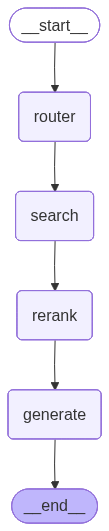

In [18]:
# снова красивое отображение структуры графа от SOTA LLM, чтобы было понятно, как узлы связаны между собой
# Граф (нотация Mermaid — отображается в Jupyter)
try:
    from IPython.display import Image, display
    img_bytes = agent_graph.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f"Визуализация недоступна: {e}")
    print()
    print("Нотация Mermaid:")
    try:
        print(agent_graph.get_graph().draw_mermaid())
    except Exception:
        print("  router → search → rerank → generate → END")

---
## 14. Запуск агента — тестовые запросы

Каждая ячейка ниже — полный прогон через граф:  
`router → search → rerank → generate`

Можно посмотреть все промежуточные выводы по мере выполнения графа.

In [19]:
# Тест 1
# Ожидаемый маршрут: dota2_heroes, entity_name="Anti-Mage"
query1 = "Расскажи про способности Anti-Mage"
print(f"{query1}")

result1 = agent_graph.invoke({"query": query1})

print("=" * 70)
print(result1["answer"])

Расскажи про способности Anti-Mage
🗺️  Маршрутизатор: {'collections': ['dota2_heroes'], 'entity_name': 'Anti-Mage', 'entity_type': 'hero'}
   🔧 dota2_heroes: where={'hero_name': {'$eq': 'Anti-Mage'}}
      → 10 кандидатов

🔍 search_node: собрано 10 кандидатов
rerank_node: реранкинг 10 кандидатов - топ 5
#1 bi=0.6958 - rerank=+0.9664 , Герой: Anti-Mage

Описание: Если Anti-Mage наберёт полную силу, мало к...
#2 bi=0.6367 - rerank=+0.9167 Counterspell, Герой: Anti-Mage

Способность: Counterspell
Макс. уровень: 4

Пассивно...
#3 bi=0.6141 - rerank=+0.8620 Persecutor, Герой: Anti-Mage

Способность: Persecutor
Макс. уровень: 4
Врождённая ...
#4 bi=0.5399 - rerank=+0.7742 Blink, Герой: Anti-Mage

Способность: Blink
Макс. уровень: 4

Перемещение на ...
#5 bi=0.5918 - rerank=+0.7668 Mana Break, Герой: Anti-Mage

Способность: Mana Break
Макс. уровень: 4

Каждая ата...
generate_node: генерирую ответ (5 контекстов, 3323 символов в промпте)
Сгенерировано 196 токенов за 5.6с (35 tok/s)
Anti-Mage им

In [20]:
# Тест 2
# Ожидаемый маршрут: dota2_patches + dota2_heroes, entity_name="Invoker"
query2 = "Что изменилось у Invoker в последних патчах?"
print(f"{query2}")

result2 = agent_graph.invoke({"query": query2})

print("=" * 70)
print(result2["answer"])

Что изменилось у Invoker в последних патчах?
🗺️  Маршрутизатор: {'collections': ['dota2_patches', 'dota2_heroes'], 'entity_name': 'Invoker', 'entity_type': 'hero'}
   🔧 dota2_patches: where={'$and': [{'hero_name': {'$eq': 'Invoker'}}, {'entity_type': {'$eq': 'hero'}}]}
      → 1 кандидатов
   🔧 dota2_heroes: where={'hero_name': {'$eq': 'Invoker'}}
      → 15 кандидатов

🔍 search_node: собрано 16 кандидатов
rerank_node: реранкинг 16 кандидатов - топ 5
#1 bi=0.6614 - rerank=+0.2773 , Патч 7.40 — Invoker

Таланты:
  • Талант 15 уровня: уменьшение перезар...
#2 bi=0.5970 - rerank=+0.2199 , Герой: Invoker

Описание: Благодаря обширному арсеналу заклинаний Invo...
#3 bi=0.5183 - rerank=+0.2090 , Герой: Invoker

Предыстория:
Магия в своей самой ранней, даже можно ск...
#4 bi=0.5956 - rerank=+0.0757 Ghost Walk, Герой: Invoker

Способность: Ghost Walk
Макс. уровень: 1

Герой комбин...
#5 bi=0.5035 - rerank=+0.0379 Chaos Meteor, Герой: Invoker

Способность: Chaos Meteor
Макс. уровень: 1

Герой н

In [21]:
# Тест 3
# Ожидаемый маршрут: dota2_items, entity_name=null (общий поиск по предметам)
query3 = "Какие предметы дают невидимость?"
print(f"Запрос 3: {query3}")

result3 = agent_graph.invoke({"query": query3})

print("=" * 70)
print(result3["answer"])

Запрос 3: Какие предметы дают невидимость?
🗺️  Маршрутизатор: {'collections': ['dota2_items'], 'entity_name': None, 'entity_type': 'item'}
   🔍 dota2_items: полный скан
      → 10 кандидатов

🔍 search_node: собрано 10 кандидатов
rerank_node: реранкинг 10 кандидатов - топ 5
#1 bi=0.6598 - rerank=+0.8041 Gem of True Sight, Предмет: Gem of True Sight

Способности:
Активное: Reveal Раскрывает н...
#2 bi=0.5661 - rerank=+0.4326 Shadow Blade, Предмет: Shadow Blade

Способности:
Активное: Shadow WalkДелает героя ...
#3 bi=0.5524 - rerank=+0.4306 Glimmer Cape, Предмет: Glimmer Cape

Способности:
Активное: Glimmer После задержки в...
#4 bi=0.6316 - rerank=+0.3358 Sentry Ward, Предмет: Sentry Ward

Способности:
Использование: Plant Устанавливает ...
#5 bi=0.5738 - rerank=+0.3224 Smoke of Deceit, Предмет: Smoke of Deceit

Способности:
Использование: Disguise Все под...
generate_node: генерирую ответ (5 контекстов, 2460 символов в промпте)
Сгенерировано 180 токенов за 4.9с (37 tok/s)
У нас есть тр

---
## 15. Удобная обёртка и интерактивный чат

Тонкая обёртка над `app.invoke()` для чистого вывода, плюс опциональный интерактивный цикл.

In [22]:
def ask(query: str, show_routing: bool = True, show_contexts: bool = False) -> str:
    """
    Удобная обёртка: запускает LangGraph-агент и выводит чистый результат.

    Args:
        query:          Вопрос пользователя
        show_routing:   Печатать JSON-план маршрутизатора
        show_contexts:  Печатать топ переранжированных контекстов перед ответом
    """
    print(f"{query}")

    state = agent_graph.invoke({"query": query})

    if show_routing:
        ro = state.get("router_output", {})
        print(f"Маршрут: коллекции={ro.get('collections')} "
              f"сущность={ro.get('entity_name')} "
              f"тип={ro.get('entity_type')}")

    if show_contexts:
        for i, ctx in enumerate(state.get("reranked_contexts", []), 1):
            print(f"{i}. rerank={ctx.get('rerank_score', 0):+.3f}, {ctx['text'][:90]}")

    print(f"Ответ:\n{state['answer']}")
    return state["answer"]

In [23]:
def dota2_chat():
    """
    Интерактивный цикл вопрос-ответ с LangGraph-агентом.
    Введи 'выход' или 'exit' для завершения.
    """

    while True:
        try:
            user_input = input("Вы: ").strip()
        except (EOFError, KeyboardInterrupt):
            print("До свидания!")
            break

        if not user_input:
            continue
        if user_input.lower() in ("exit", "quit", "выход", "q"):
            print("До свидания!")
            break

        ask(user_input, show_routing=True, show_contexts=False)
        print()


# Раскомментируй для запуска интерактивного чата:
# dota2_chat()